Well , I was test about three model : LightGBM,SVM and XGBoost . Gemini said the feature doesn't really good to predict Web-based . The highest F1-Score was LightGBM with 73% . Can someone give me some advices;-;


In [1]:
import pandas as pd
import numpy as np
import os
import glob

SELECTED_FEATURES = [
    'IAT', 'syn_flag_number', 'psh_flag_number', 'fin_flag_number', 
    'rst_flag_number', 'ack_flag_number', 'Tot sum', 'Protocol Type', 
    'flow_duration', 'Rate', 'Std', 'Variance', 'UDP', 'TCP', 'HTTP', 
    'HTTPS', 'DNS', 'Duration', 'Number', 'ICMP', 'Magnitue', 
    'Header_Length', 'AVG', 'Min', 'Max'
]

INPUT_DIR        = '/kaggle/input/datasets/nguyenleanhtuan07/b-data-scale-encoding-v-chia-theo-tng-label/'
LABEL_MAP_PATH   = '/kaggle/input/datasets/nguyenleanhtuan07/nhn-34/label_map_key.csv'
OUTPUT_DATA      = '/kaggle/working/layer3_web_all6labels_data.csv.gz'
SAMPLES_PER_FILE = 100_000

TARGET_LABELS = [
    'Backdoor_Malware',
    'Uploading_Attack',
    'SqlInjection',
    'CommandInjection',
    'XSS',
    'BrowserHijacking',
]

def basic_clean(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    return df

def process_layer3():
    label_lookup = pd.read_csv(LABEL_MAP_PATH)
    csv_files    = glob.glob(os.path.join(INPUT_DIR, '*.csv'))
    print(f"Bắt đầu trích xuất Layer 3 (6 nhãn, 1 file) trên {len(csv_files)} file...")

    first_write  = True
    label_counts = {label: 0 for label in TARGET_LABELS}

    for file_path in csv_files:
        temp_df = pd.read_csv(file_path, nrows=1)
        if 'label' not in temp_df.columns:
            continue
        label_id = temp_df['label'].iloc[0]

        match = label_lookup[label_lookup['Encoded_ID'] == label_id]
        if match.empty:
            continue
        original_name = match['Original_Label'].values[0]

        if original_name not in TARGET_LABELS:
            continue

        available_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
        use_cols       = [c for c in SELECTED_FEATURES if c in available_cols]
        df_full        = pd.read_csv(file_path, usecols=use_cols)

        df_cleaned = basic_clean(df_full)
        if len(df_cleaned) == 0:
            continue

        num_sample = min(len(df_cleaned), SAMPLES_PER_FILE)
        df_sampled = df_cleaned.sample(n=num_sample, random_state=42)
        df_sampled['layer3_label'] = original_name  # tên nhãn cụ thể

        label_counts[original_name] += num_sample

        if first_write:
            df_sampled.to_csv(OUTPUT_DATA, index=False, compression='gzip')
            first_write = False
        else:
            df_sampled.to_csv(OUTPUT_DATA, mode='a', index=False,
                              header=False, compression='gzip')

        print(f"Đã xử lý: {original_name} ({num_sample:,} dòng)")
        del df_full, df_cleaned, df_sampled

    print("\n--- TỔNG KẾT DỮ LIỆU LAYER 3 (6 NHÃN) ---")
    for label, count in label_counts.items():
        status = f"{count:,} dòng" if count > 0 else "KHÔNG CÓ DỮ LIỆU"
        print(f"  {label:25}: {status}")
    print(f"\nFile lưu tại: {OUTPUT_DATA}")
    print("--- HOÀN TẤT ---")

if __name__ == "__main__":
    process_layer3()

Bắt đầu trích xuất Layer 3 (6 nhãn, 1 file) trên 34 file...
Đã xử lý: SqlInjection (5,245 dòng)
Đã xử lý: XSS (3,846 dòng)
Đã xử lý: Uploading_Attack (1,252 dòng)
Đã xử lý: Backdoor_Malware (3,218 dòng)
Đã xử lý: BrowserHijacking (5,859 dòng)
Đã xử lý: CommandInjection (5,409 dòng)

--- TỔNG KẾT DỮ LIỆU LAYER 3 (6 NHÃN) ---
  Backdoor_Malware         : 3,218 dòng
  Uploading_Attack         : 1,252 dòng
  SqlInjection             : 5,245 dòng
  CommandInjection         : 5,409 dòng
  XSS                      : 3,846 dòng
  BrowserHijacking         : 5,859 dòng

File lưu tại: /kaggle/working/layer3_web_all6labels_data.csv.gz
--- HOÀN TẤT ---



  LAYER 3 — Mô hình: Web_Layer3_6Labels
Các lớp tấn công cụ thể: ['Backdoor_Malware', 'BrowserHijacking', 'CommandInjection', 'SqlInjection', 'Uploading_Attack', 'XSS']
Số mẫu: 24,829  |  Số đặc trưng: 20
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[91]	valid_0's multi_logloss: 0.605277
   + Hoàn thành Fold 1 | F1: 0.7294
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[112]	valid_0's multi_logloss: 0.59316
   + Hoàn thành Fold 2 | F1: 0.7460
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[96]	valid_0's multi_logloss: 0.597907
   + Hoàn thành Fold 3 | F1: 0.7333
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[114]	valid_0's multi_logloss: 0.600683
   + Hoàn thành Fold 4 | F1: 0.7388
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[96]	valid_0'

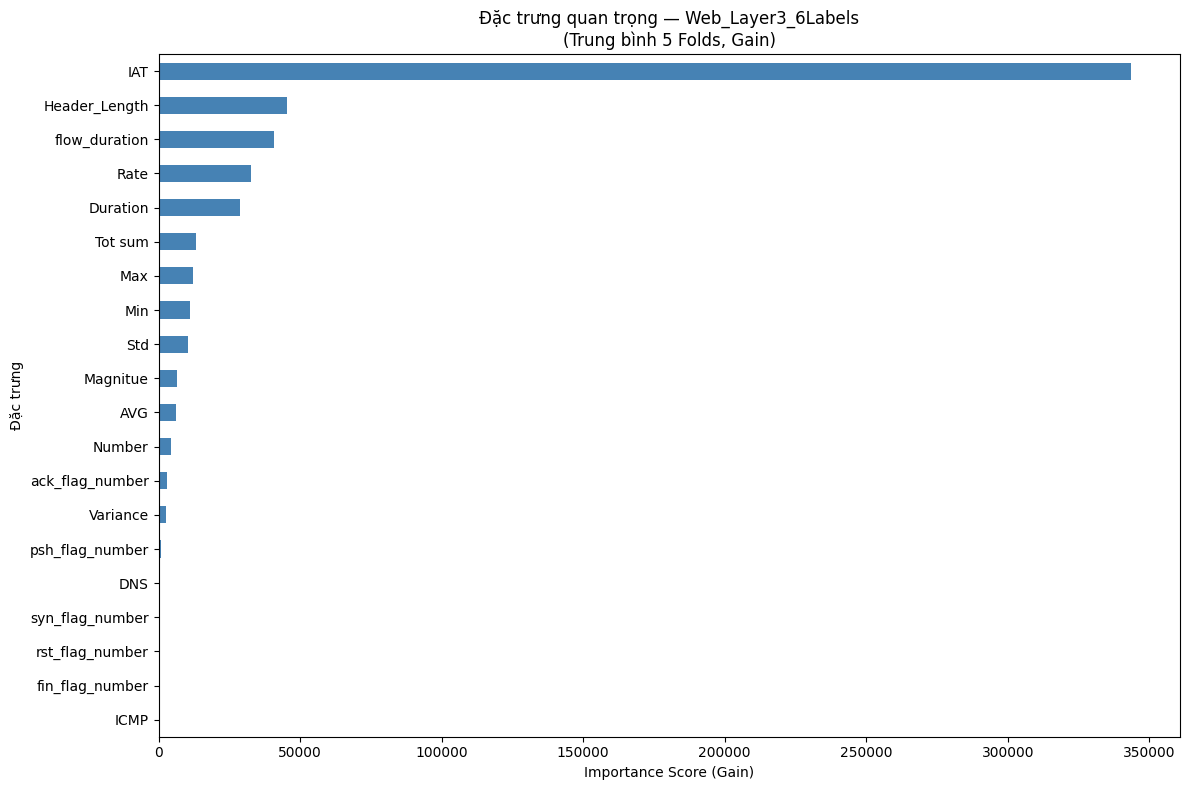

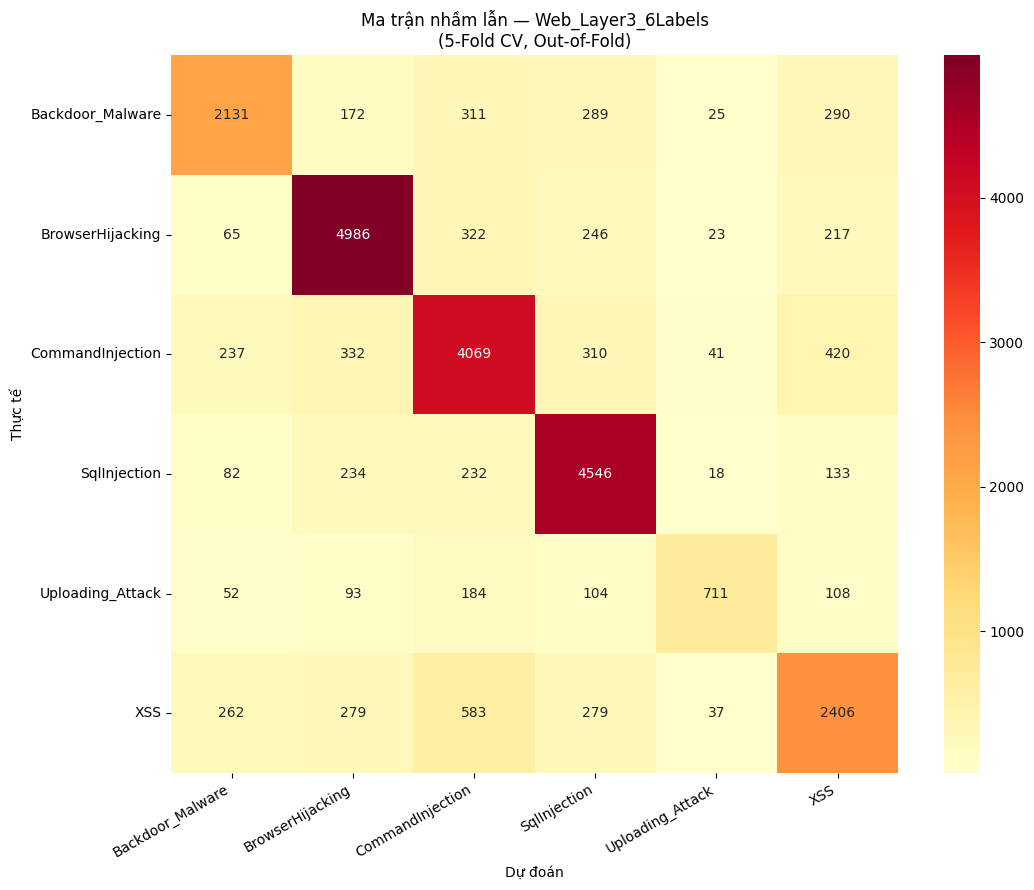


HOÀN TẤT LAYER 3 — 6 NHÃN WEB.


In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

K_FOLDS = 5

config = {
    'name':       'Web_Layer3_6Labels',
    'input_file': '/kaggle/working/layer3_web_all6labels_data.csv.gz',
    'fig_imp':    '/kaggle/working/layer3_web_6labels_feature_importance.png',
    'fig_cm':     '/kaggle/working/layer3_web_6labels_confusion_matrix.png',
}

COLS_TO_DROP_ALWAYS = ['Protocol Type', 'TCP', 'UDP', 'HTTP', 'HTTPS']

name = config['name']
print(f"\n{'='*60}")
print(f"  LAYER 3 — Mô hình: {name}")
print(f"{'='*60}")

df = pd.read_csv(config['input_file'])
df.columns = df.columns.str.strip()

target_col   = 'layer3_label' if 'layer3_label' in df.columns else df.columns[-1]
drop_cols    = [c for c in COLS_TO_DROP_ALWAYS + [target_col] if c in df.columns]
X            = df.drop(columns=drop_cols)
y_raw        = df[target_col]

le           = LabelEncoder()
y            = pd.Series(le.fit_transform(y_raw))
target_names = le.classes_
n_classes    = len(target_names)

print(f"Các lớp tấn công cụ thể: {list(target_names)}")
print(f"Số mẫu: {len(df):,}  |  Số đặc trưng: {X.shape[1]}")

skf          = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_metrics = []
all_latency  = []
oof_preds    = np.zeros(len(df))
feat_imp_df  = pd.DataFrame()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    params = {
        'objective':        'multiclass',
        'num_class':        n_classes,
        'metric':           'multi_logloss',
        'is_unbalance':     True,
        'learning_rate':    0.05,
        'num_leaves':       63,
        'max_bin':          255,
        'min_data_in_leaf': 50,
        'device':           'cpu',
        'verbose':          -1,
        'seed':             42
    }

    train_set = lgb.Dataset(X_train, label=y_train)
    val_set   = lgb.Dataset(X_val,   label=y_val, reference=train_set)

    model = lgb.train(
        params, train_set,
        valid_sets=[val_set],
        num_boost_round=2000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=0)
        ]
    )

    t0             = time.time()
    y_prob         = model.predict(X_val)
    t1             = time.time()
    y_pred         = np.argmax(y_prob, axis=1)
    oof_preds[val_idx] = y_pred

    all_latency.append((t1 - t0) / len(X_val))

    fold_imp = pd.DataFrame({
        'Feature':    X.columns,
        'Importance': model.feature_importance(importance_type='gain')
    })
    feat_imp_df = pd.concat([feat_imp_df, fold_imp], axis=0)

    fold_metrics.append({
        'accuracy':  accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, average='macro', zero_division=0),
        'recall':    recall_score(y_val, y_pred, average='macro', zero_division=0),
        'f1':        f1_score(y_val, y_pred, average='macro', zero_division=0)
    })
    print(f"   + Hoàn thành Fold {fold + 1} | F1: {fold_metrics[-1]['f1']:.4f}")

# --- Tổng hợp kết quả ---
metrics_df = pd.DataFrame(fold_metrics)
avg_m      = metrics_df.mean()
std_m      = metrics_df.std()
avg_lat_ms = np.mean(all_latency) * 1000

print(f"\n{'='*50}")
print(f"  KẾT QUẢ TRUNG BÌNH ({K_FOLDS}-FOLD) — {name}")
print(f"{'-'*50}")
print(f"1. Accuracy:  {avg_m['accuracy']:.4f}  (±{std_m['accuracy']:.4f})")
print(f"2. Precision: {avg_m['precision']:.4f}  (±{std_m['precision']:.4f})")
print(f"3. Recall:    {avg_m['recall']:.4f}  (±{std_m['recall']:.4f})")
print(f"4. F1-Score:  {avg_m['f1']:.4f}  (±{std_m['f1']:.4f})")
print(f"{'-'*50}")
print(f"Tốc độ dự đoán: {avg_lat_ms:.6f} ms/dòng")
print(f"{'='*50}")

print(f"\nBáo cáo phân loại chi tiết (Out-of-Fold):")
print(classification_report(y, oof_preds, target_names=target_names, zero_division=0))

# --- Feature importance ---
plt.figure(figsize=(12, 8))
mean_imp = (feat_imp_df.groupby('Feature')['Importance']
                       .mean()
                       .sort_values(ascending=True))
mean_imp.plot(kind='barh', color='steelblue')
plt.title(f'Đặc trưng quan trọng — {name}\n(Trung bình {K_FOLDS} Folds, Gain)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.savefig(config['fig_imp'])
plt.show()

# --- Confusion matrix ---
cm    = confusion_matrix(y, oof_preds)
fig_h = max(8, n_classes * 1.5)
plt.figure(figsize=(fig_h + 2, fig_h))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Ma trận nhầm lẫn — {name}\n({K_FOLDS}-Fold CV, Out-of-Fold)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(config['fig_cm'])
plt.show()

print("\nHOÀN TẤT LAYER 3 — 6 NHÃN WEB.")


In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import time
from sklearn.preprocessing import LabelEncoder

config = {
    'name':        'Web_Layer3_6Labels',
    'input_file':  '/kaggle/working/layer3_web_all6labels_data.csv.gz',
    'model_out':   '/kaggle/working/lightgbm_layer3_web_6labels_model.txt',
    'encoder_out': '/kaggle/working/layer3_web_6labels_encoder.pkl',
    'meta_out':    '/kaggle/working/layer3_web_6labels_meta.pkl',
}

# ĐÃ SỬA: Để trống danh sách này để giữ lại các cột Protocol Type (TCP, UDP, HTTP, HTTPS)
COLS_TO_DROP = []  

name = config['name']
print(f"\n{'='*60}")
print(f"=> Đang tải dữ liệu: {name}...")

df = pd.read_csv(config['input_file'])
df.columns = df.columns.str.strip()

drop_cols = [c for c in COLS_TO_DROP + ['layer3_label'] if c in df.columns]
X     = df.drop(columns=drop_cols)
y_raw = df['layer3_label']

print(f"=> Đang mã hóa nhãn và lưu LabelEncoder...")
le = LabelEncoder()
y  = le.fit_transform(y_raw)

with open(config['encoder_out'], 'wb') as f:
    pickle.dump(le, f)
print(f"   + Đã nhận diện các lớp: {list(le.classes_)}")
print(f"   + Đặc trưng sử dụng   : {list(X.columns)}")

n_classes = len(np.unique(y))

params = {
    'objective':     'multiclass',
    'num_class':     n_classes,
    'metric':        'multi_logloss',
    'is_unbalance':  True,
    'learning_rate': 0.015,
    'num_leaves':    255,
    'max_bin':       511,
    'device':        'cpu',
    'verbose':       -1,
    'seed':          42
}

print(f"\n=> Đang huấn luyện {name} trên toàn bộ {len(df):,} dòng dữ liệu...")
start_time = time.time()

train_set   = lgb.Dataset(X, label=y)
final_model = lgb.train(params, train_set, num_boost_round=2000)

training_duration = time.time() - start_time
print(f"\n=> Huấn luyện hoàn tất trong {training_duration:.2f} giây.")

final_model.save_model(config['model_out'])
print(f"   [+] Đã lưu mô hình tại : {config['model_out']}")

model_info = {
    'features':  list(X.columns),
    'num_class': n_classes
}
with open(config['meta_out'], 'wb') as f:
    pickle.dump(model_info, f)
print(f"   [+] Đã lưu meta tại    : {config['meta_out']}")
print(f"   [+] Đã lưu encoder tại : {config['encoder_out']}")

print(f"\n{'='*60}")
print("=> HỆ THỐNG TẦNG 3 WEB (6 NHÃN) ĐÃ SẴN SÀNG!")



=> Đang tải dữ liệu: Web_Layer3_6Labels...
=> Đang mã hóa nhãn và lưu LabelEncoder...
   + Đã nhận diện các lớp: ['Backdoor_Malware', 'BrowserHijacking', 'CommandInjection', 'SqlInjection', 'Uploading_Attack', 'XSS']
   + Đặc trưng sử dụng   : ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'HTTP', 'HTTPS', 'DNS', 'TCP', 'UDP', 'ICMP', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'IAT', 'Number', 'Magnitue', 'Variance']

=> Đang huấn luyện Web_Layer3_6Labels trên toàn bộ 24,829 dòng dữ liệu...

=> Huấn luyện hoàn tất trong 205.83 giây.
   [+] Đã lưu mô hình tại : /kaggle/working/lightgbm_layer3_web_6labels_model.txt
   [+] Đã lưu meta tại    : /kaggle/working/layer3_web_6labels_meta.pkl
   [+] Đã lưu encoder tại : /kaggle/working/layer3_web_6labels_encoder.pkl

=> HỆ THỐNG TẦNG 3 WEB (6 NHÃN) ĐÃ SẴN SÀNG!


In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import os
import glob
import random

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN (1 MÔ HÌNH — 6 NHÃN)
# ==========================================
MODEL_PATH         = '/kaggle/working/lightgbm_layer3_web_6labels_model.txt'
LABEL_ENCODER_PATH = '/kaggle/working/layer3_web_6labels_encoder.pkl'
META_DATA_PATH     = '/kaggle/working/layer3_web_6labels_meta.pkl'

INPUT_DIR      = '/kaggle/input/datasets/nguyenleanhtuan07/b-data-scale-encoding-v-chia-theo-tng-label/'
LABEL_MAP_PATH = '/kaggle/input/datasets/nguyenleanhtuan07/nhn-34/label_map_key.csv'

ALL_WEB_LABELS = [
    'Backdoor_Malware', 'Uploading_Attack',
    'SqlInjection', 'CommandInjection', 'XSS', 'BrowserHijacking'
]

print("=> Đang khởi động hệ thống AI Web Layer 3 (6 nhãn)...")
model = lgb.Booster(model_file=MODEL_PATH)
with open(LABEL_ENCODER_PATH, 'rb') as f: le = pickle.load(f)
with open(META_DATA_PATH,     'rb') as f: expected_features = pickle.load(f)['features']
print(f"   [+] Các lớp nhận diện: {list(le.classes_)}")

# ==========================================
# 2. SINH TRỌNG SỐ ĐẶC TRƯNG
# ==========================================
print("\n" + "="*55)
print("⭐ BƯỚC 1: TRÍCH XUẤT TRỌNG SỐ ĐẶC TRƯNG (WEB 6 NHÃN)")
print("="*55)

weights   = model.feature_importance(importance_type='gain')
weight_df = pd.DataFrame({
    'Feature':       expected_features,
    'Weight (Gain)': weights
})
weight_df = weight_df.sort_values(by='Weight (Gain)', ascending=False)
weight_df['Contribution (%)'] = (weight_df['Weight (Gain)'] / weight_df['Weight (Gain)'].sum()) * 100

print(weight_df.head(10).to_string(index=False))
weight_df.to_csv('/kaggle/working/layer3_web_6labels_feature_weights.txt', index=False, sep='\t')
print("\n[+] Đã lưu trọng số tại: layer3_web_6labels_feature_weights.txt")

# ==========================================
# 3. THUẬT TOÁN GOM RỔ DỮ LIỆU ĐẢM BẢO ĐỦ 10 MẪU
# ==========================================
print("\n" + "="*60)
print("🚀 BƯỚC 2: BLIND TEST ĐẢM BẢO ĐỦ 10 MẪU TRÊN DATA GỐC")
print("="*60)

csv_files    = glob.glob(os.path.join(INPUT_DIR, "*.csv"))
label_lookup = pd.read_csv(LABEL_MAP_PATH)
label_dict   = dict(zip(label_lookup['Encoded_ID'], label_lookup['Original_Label']))

random.shuffle(csv_files)
sample_pool      = []
target_count     = 10
samples_per_file = 4

print("=> Đang rải lưới quét dữ liệu Web (6 nhãn)...")

for file_path in csv_files:
    temp_df = pd.read_csv(file_path, nrows=1)
    if 'label' not in temp_df.columns: continue

    label_id      = temp_df['label'].iloc[0]
    original_name = label_dict.get(label_id, "")

    if original_name not in ALL_WEB_LABELS:
        continue

    available_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
    use_cols       = [c for c in expected_features if c in available_cols]

    df_raw     = pd.read_csv(file_path, usecols=use_cols)
    df_cleaned = df_raw.replace([np.inf, -np.inf], np.nan).dropna()

    if len(df_cleaned) > 0:
        take_n     = min(len(df_cleaned), samples_per_file)
        df_sampled = df_cleaned.sample(n=take_n)
        df_sampled['True_Answer'] = original_name
        sample_pool.append(df_sampled)

    if sum(len(d) for d in sample_pool) >= target_count * 2:
        break

# ==========================================
# 4. CHỐT SỔ VÀ DỰ ĐOÁN
# ==========================================
if not sample_pool:
    print("⚠️ Không tìm thấy mẫu Web nào.")
else:
    master_df = pd.concat(sample_pool, ignore_index=True)

    if len(master_df) >= target_count:
        test_df = master_df.sample(n=target_count).reset_index(drop=True)
    else:
        test_df = master_df.sample(frac=1.0).reset_index(drop=True)

    true_labels = test_df['True_Answer'].tolist()
    X_test      = test_df[expected_features].apply(pd.to_numeric, errors='coerce').fillna(0)

    y_prob         = model.predict(X_test)
    y_pred_indices = np.argmax(y_prob, axis=1)
    confidences    = np.max(y_prob, axis=1) * 100
    y_pred_names   = le.inverse_transform(y_pred_indices)

    correct_count = 0
    for i in range(len(test_df)):
        is_correct = (true_labels[i] == y_pred_names[i])
        if is_correct: correct_count += 1

        print(f"STT {i+1}:")
        print(f"   - Thực tế : {true_labels[i]}")
        print(f"   - AI đoán : {y_pred_names[i]} (Độ tự tin: {confidences[i]:.2f}%)")
        print(f"   => {'✅ CHÍNH XÁC' if is_correct else '❌ SAI LỆCH'}")
        print("-" * 50)

    print(f"🏆 TỔNG KẾT: Đúng {correct_count}/{len(test_df)} mẫu.")

=> Đang khởi động hệ thống AI Web Layer 3 (6 nhãn)...
   [+] Các lớp nhận diện: ['Backdoor_Malware', 'BrowserHijacking', 'CommandInjection', 'SqlInjection', 'Uploading_Attack', 'XSS']

⭐ BƯỚC 1: TRÍCH XUẤT TRỌNG SỐ ĐẶC TRƯNG (WEB 6 NHÃN)
      Feature  Weight (Gain)  Contribution (%)
          IAT   1.405944e+06         49.386854
Header_Length   2.463109e+05          8.652207
flow_duration   2.272809e+05          7.983738
         Rate   2.001914e+05          7.032159
     Duration   1.481919e+05          5.205563
      Tot sum   9.212783e+04          3.236191
          Max   8.722229e+04          3.063873
          Min   8.399755e+04          2.950597
          Std   8.018665e+04          2.816731
Protocol Type   6.980332e+04          2.451994

[+] Đã lưu trọng số tại: layer3_web_6labels_feature_weights.txt

🚀 BƯỚC 2: BLIND TEST ĐẢM BẢO ĐỦ 10 MẪU TRÊN DATA GỐC
=> Đang rải lưới quét dữ liệu Web (6 nhãn)...
STT 1:
   - Thực tế : XSS
   - AI đoán : XSS (Độ tự tin: 100.00%)
   => ✅ CHÍNH 